### Импорт библиотек

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

###Загрузка данных с учётом специфики разделителей

In [13]:
data = pd.read_csv('IMOEX_data.csv', thousands='.', decimal=',', dtype={'Дата': str})

###Разворот и сброс индекса

In [14]:
data = data.iloc[::-1].reset_index(drop=True)

###Преобразование даты и установка индекса

In [15]:
data['Дата'] = pd.to_datetime(data['Дата'], format='%d.%m.%Y')
data.set_index('Дата', inplace=True)

###Расчёт скользящих средних по столбцу 'Цена'

In [16]:
data['MA_10'] = data['Цена'].rolling(window=10).mean()
data['MA_50'] = data['Цена'].rolling(window=50).mean()

###Построение графика

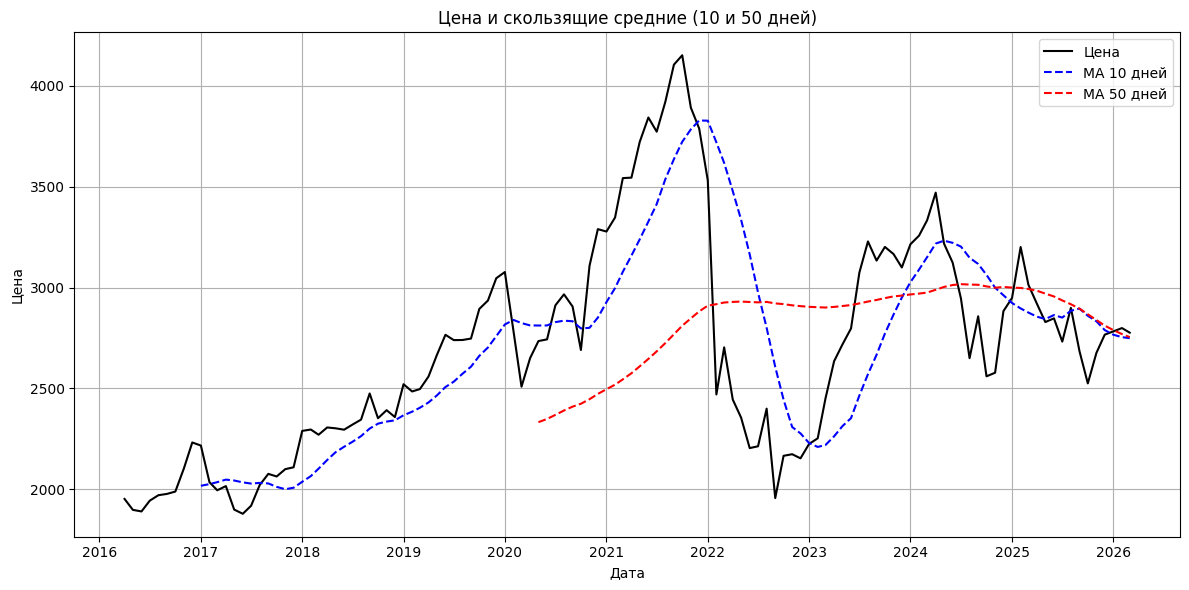

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Цена'], label='Цена', color='black')
plt.plot(data.index, data['MA_10'], label='MA 10 дней', linestyle='--', color='blue')
plt.plot(data.index, data['MA_50'], label='MA 50 дней', linestyle='--', color='red')
plt.title('Цена и скользящие средние (10 и 50 дней)')
plt.xlabel('Дата')
plt.ylabel('Цена')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()